# Samantha Kanny
## CSCI E-89 Deep Learning
## Homework 03, Problem 2

## Project overview

This notebook builds an end-to-end FashionMNIST image classifier with PyTorch and TorchVision:

1. Load and inspect the FashionMNIST dataset.
2. Build, train, and evaluate a fully connected `ImageClassifier`.
3. Tune the learning rate and hidden-layer width with Optuna (a basic study, then a pruning-enabled study).
4. Demonstrate three ways to save and load a trained model.
5. Optimize the trained model for inference with `torch.compile()` and `torch.export()`.
6. Plot the final training and validation accuracy curve.

Running all cells in order (Kernel → Restart & Run All) reproduces the whole pipeline.

## 1. Imports

We import `torch`, `torchvision`, the `v2` transforms API, and `DataLoader`.

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

## 2. Transform

We build a transform pipeline that converts each PIL image into a tensor image (`T.ToImage()`) and casts it to `float32` with pixel values scaled to the range 0-1 (`T.ToDtype(torch.float32, scale=True)`).

In [2]:
transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

## 3. Download the dataset

We download the FashionMNIST training and test sets into a `datasets` folder. The full 60,000-observation training set is stored as `train_and_valid_data`, and the 10,000-observation test set is stored as `test_data`.

In [3]:
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.FashionMNIST(
    root="datasets",
    train=False,
    download=True,
    transform=transform
)

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<01:24, 311kB/s]

  0%|          | 65.5k/26.4M [00:00<01:26, 305kB/s]

  0%|          | 98.3k/26.4M [00:00<01:26, 304kB/s]

  1%|          | 229k/26.4M [00:00<00:39, 662kB/s] 

...

 27%|██▋       | 1.18M/4.42M [00:00<00:01, 2.68MB/s]

 53%|█████▎    | 2.36M/4.42M [00:00<00:00, 5.24MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 5.01MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 9.45MB/s]

## 4. Train/validation split

We set the PyTorch random seed to 42 for reproducibility, then split the 60,000 training observations into 55,000 training observations (`train_data`) and 5,000 validation observations (`valid_data`).

In [4]:
torch.manual_seed(42)

train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55000, 5000]
)

## 5. DataLoaders

We wrap each dataset split in a `DataLoader` with a batch size of 32, shuffling only the training data.

In [5]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

## 6. Inspect a sample

We retrieve the first observation from `train_data` as `X_sample` (the image tensor) and `y_sample` (the integer class label).

In [6]:
X_sample, y_sample = train_data[0]

### Shape of `X_sample`

In [7]:
X_sample.shape

torch.Size([1, 28, 28])

### Data type of `X_sample`

In [8]:
X_sample.dtype

torch.float32

### Class name for `y_sample`

In [9]:
train_and_valid_data.classes[y_sample]

'Ankle boot'

## 7. Imports for the classifier

We import `torch.nn`, `torch.nn.functional`, TorchMetrics for the accuracy metric, and Matplotlib for plotting. We also select the best available device: CUDA, then Apple Silicon MPS, then CPU.

In [10]:
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import matplotlib.pyplot as plt

# Prefer CUDA, then Apple Silicon (MPS), then fall back to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## 8. Define the `ImageClassifier` model

A fully connected network: flatten the image, then two hidden layers (sized by `n_hidden1` and `n_hidden2`, defaulting to 300 and 100 units) with ReLU activations, ending in an `n_classes`-way output layer of raw logits. `n_inputs`, `n_hidden1`, `n_hidden2`, and `n_classes` are all constructor arguments so the architecture can be searched over or reconstructed from saved hyperparameters later.

In [11]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(n_inputs, n_hidden1)
        self.fc2 = nn.Linear(n_hidden1, n_hidden2)
        self.fc3 = nn.Linear(n_hidden2, n_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # raw logits; CrossEntropyLoss applies softmax internally
        return x

## 9. Instantiate the model and loss function

We set the random seed to 42 for reproducible weight initialization, create the model on the selected device, and use cross-entropy loss for multiclass classification.

In [12]:
torch.manual_seed(42)

model = ImageClassifier().to(device)  # move model parameters to the selected device
loss_fn = nn.CrossEntropyLoss()

## 10. Optimizer and accuracy metric

We use plain SGD with a learning rate of 0.1, and a TorchMetrics `MulticlassAccuracy` metric configured for 10 classes.

In [13]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy_metric = torchmetrics.classification.MulticlassAccuracy(num_classes=10).to(device)

## 11. Training function

`train2` runs a full training loop for a given number of epochs: it trains on `train_loader`, evaluates on `valid_loader`, and records the loss/accuracy for both epoch by epoch. It is reused unchanged later for hyperparameter tuning.

In [14]:
def train2(model, train_loader, valid_loader, optimizer, loss_fn, accuracy_metric, epochs, device):
    """Train `model` and return a history dict of per-epoch loss/accuracy."""
    history = {"train_loss": [], "valid_loss": [], "train_metrics": [], "valid_metrics": []}

    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        accuracy_metric.reset()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move batch to device

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            accuracy_metric.update(logits, y_batch)

        train_loss = running_loss / len(train_loader.dataset)
        train_metric = accuracy_metric.compute().item()

        # --- Validation phase ---
        model.eval()
        running_loss = 0.0
        accuracy_metric.reset()

        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                logits = model(X_batch)
                loss = loss_fn(logits, y_batch)

                running_loss += loss.item() * X_batch.size(0)
                accuracy_metric.update(logits, y_batch)

        valid_loss = running_loss / len(valid_loader.dataset)
        valid_metric = accuracy_metric.compute().item()

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss: {train_loss:.4f}  train_metric: {train_metric:.4f} | "
            f"valid_loss: {valid_loss:.4f}  valid_metric: {valid_metric:.4f}"
        )

    return history

## 12. Train the model

We train for a small number of epochs, printing training and validation loss/accuracy after every epoch.

In [15]:
n_epochs = 10
history = train2(
    model, train_loader, valid_loader, optimizer, loss_fn, accuracy_metric, n_epochs, device
)

Epoch 1/10 | train_loss: 0.6061  train_metric: 0.7813 | valid_loss: 0.4475  valid_metric: 0.8443


Epoch 2/10 | train_loss: 0.4061  train_metric: 0.8495 | valid_loss: 0.4245  valid_metric: 0.8430


Epoch 3/10 | train_loss: 0.3630  train_metric: 0.8660 | valid_loss: 0.3969  valid_metric: 0.8507


Epoch 4/10 | train_loss: 0.3354  train_metric: 0.8767 | valid_loss: 0.3651  valid_metric: 0.8652


Epoch 5/10 | train_loss: 0.3154  train_metric: 0.8827 | valid_loss: 0.3379  valid_metric: 0.8798


Epoch 6/10 | train_loss: 0.2994  train_metric: 0.8866 | valid_loss: 0.3608  valid_metric: 0.8653


Epoch 7/10 | train_loss: 0.2852  train_metric: 0.8924 | valid_loss: 0.3362  valid_metric: 0.8755


Epoch 8/10 | train_loss: 0.2743  train_metric: 0.8961 | valid_loss: 0.3366  valid_metric: 0.8748


Epoch 9/10 | train_loss: 0.2630  train_metric: 0.9007 | valid_loss: 0.3380  valid_metric: 0.8813


Epoch 10/10 | train_loss: 0.2525  train_metric: 0.9041 | valid_loss: 0.3333  valid_metric: 0.8773


## 13. Plot training and validation accuracy

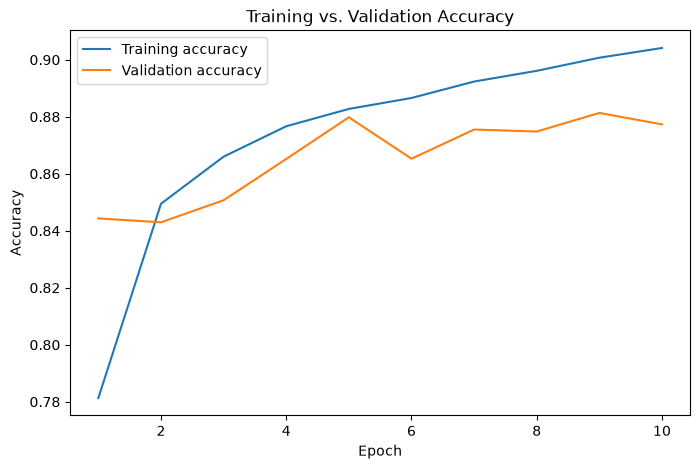

In [16]:
epochs_range = range(1, n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_metrics"], label="Training accuracy")
plt.plot(epochs_range, history["valid_metrics"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.show()

## 14. Grab a validation batch for inspection

We switch the model to evaluation mode, pull one batch from `valid_loader`, and keep only the first three images and labels.

In [17]:
model.eval()  # disable dropout/batchnorm-style training behavior (none here, but good practice)

X_batch, y_batch = next(iter(valid_loader))
X_new = X_batch[:3]
y_new = y_batch[:3]

## 15. Generate predictions for the three images

We run the images through the model under `torch.no_grad()` (no need to track gradients for inference) and move the resulting logits back to the CPU.

In [18]:
with torch.no_grad():
    logits = model(X_new.to(device)).cpu()  # move input to device, bring logits back to CPU

predicted_labels = logits.argmax(dim=1)
predicted_classes = [train_and_valid_data.classes[label] for label in predicted_labels]

print("Predicted labels:", predicted_labels.tolist())
print("Predicted classes:", predicted_classes)

Predicted labels: [7, 4, 2]
Predicted classes: ['Sneaker', 'Coat', 'Pullover']


## 16. Actual labels for comparison

In [19]:
actual_classes = [train_and_valid_data.classes[label] for label in y_new]

print("Actual labels:", y_new.tolist())
print("Actual classes:", actual_classes)

Actual labels: [7, 4, 2]
Actual classes: ['Sneaker', 'Coat', 'Pullover']


## 17. Class probabilities via softmax

Applying softmax converts the raw logits into probabilities across all 10 classes, rounded to three decimal places for readability.

In [20]:
probabilities = F.softmax(logits, dim=1)

torch.set_printoptions(sci_mode=False)
print(torch.round(probabilities, decimals=3))

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0020, 0.0000, 0.9750, 0.0000,
         0.0220],
        [0.0000, 0.0000, 0.0190, 0.0000, 0.9780, 0.0000, 0.0030, 0.0000, 0.0000,
         0.0000],
        [0.0060, 0.0000, 0.6330, 0.0010, 0.0620, 0.0000, 0.2980, 0.0000, 0.0000,
         0.0000]])


## 18. Top-4 predictions per image

`torch.topk()` picks out the four highest logits (and their matching probabilities, class indices, and class names) for each of the three images.

In [21]:
top_logits, top_indices = torch.topk(logits, k=4, dim=1)
top_probs = probabilities.gather(1, top_indices)

for i in range(len(X_new)):
    print(f"\nImage {i}:")
    for logit, prob, idx in zip(top_logits[i], top_probs[i], top_indices[i]):
        class_name = train_and_valid_data.classes[idx.item()]
        print(
            f"  logit={logit.item():.3f}  prob={prob.item():.3f}  "
            f"class_idx={idx.item()}  class_name={class_name}"
        )


Image 0:
  logit=8.887  prob=0.975  class_idx=7  class_name=Sneaker
  logit=5.114  prob=0.022  class_idx=9  class_name=Ankle boot
  logit=2.902  prob=0.002  class_idx=5  class_name=Sandal
  logit=-0.421  prob=0.000  class_idx=8  class_name=Bag

Image 1:
  logit=12.420  prob=0.978  class_idx=4  class_name=Coat
  logit=8.469  prob=0.019  class_idx=2  class_name=Pullover
  logit=6.607  prob=0.003  class_idx=6  class_name=Shirt
  logit=0.275  prob=0.000  class_idx=8  class_name=Bag

Image 2:
  logit=7.004  prob=0.633  class_idx=2  class_name=Pullover
  logit=6.252  prob=0.298  class_idx=6  class_name=Shirt
  logit=4.682  prob=0.062  class_idx=4  class_name=Coat
  logit=2.305  prob=0.006  class_idx=0  class_name=T-shirt/top


## 19. Total number of model parameters

In [22]:
total_params = sum(param.numel() for param in model.parameters())
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 266,610


## 20. Import Optuna

In [23]:
import optuna  # hyperparameter optimization framework

## 21. Define the objective function

For every trial, Optuna suggests a learning rate (log scale) and a hidden-layer width, then a brand new model/optimizer/loss/metric is built and trained for 10 epochs with the existing `train2()` function. The objective returns the best validation accuracy seen during training, which Optuna will try to maximize.

In [24]:
def objective(trial):
    # Sample a learning rate on a log scale and a hidden-layer width
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    # Build a completely new model, optimizer, loss function, and metric for this trial
    model = ImageClassifier(n_hidden1=n_hidden, n_hidden2=n_hidden).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    accuracy_metric = torchmetrics.classification.MulticlassAccuracy(num_classes=10).to(device)

    # Train for 10 epochs using the existing training function
    history = train2(model, train_loader, valid_loader, optimizer, loss_fn, accuracy_metric, 10, device)

    # Optuna maximizes the returned value, so report the best validation accuracy
    return max(history["valid_metrics"])

## 22. Seed and sampler

We reset the random seed for reproducible model initialization and create a `TPESampler` with a fixed seed so the search itself is reproducible.

In [25]:
torch.manual_seed(42)  # reproducible model weight initialization across trials

sampler = optuna.samplers.TPESampler(seed=42)  # reproducible hyperparameter sampling

## 23. Create and run the study

We create a study that maximizes validation accuracy and run 5 trials.

In [26]:
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-09-20 19:43:42,589] A new study created in memory with name: no-name-b9195838-28b8-4280-bb21-30fc2cd52d49


Epoch 1/10 | train_loss: 2.2769  train_metric: 0.1471 | valid_loss: 2.2444  valid_metric: 0.1846


Epoch 2/10 | train_loss: 2.2093  train_metric: 0.2793 | valid_loss: 2.1672  valid_metric: 0.3534


Epoch 3/10 | train_loss: 2.1164  train_metric: 0.4106 | valid_loss: 2.0533  valid_metric: 0.4577


Epoch 4/10 | train_loss: 1.9776  train_metric: 0.5136 | valid_loss: 1.8877  valid_metric: 0.5562


...

Epoch 7/10 | train_loss: 0.5385  train_metric: 0.8163 | valid_loss: 0.5546  valid_metric: 0.8098


Epoch 8/10 | train_loss: 0.5158  train_metric: 0.8242 | valid_loss: 0.5306  valid_metric: 0.8218


Epoch 9/10 | train_loss: 0.4988  train_metric: 0.8280 | valid_loss: 0.5204  valid_metric: 0.8229


[I 2026-09-20 19:52:13,061] Trial 4 finished with value: 0.8229196071624756 and parameters: {'lr': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8549988269805908.


Epoch 10/10 | train_loss: 0.4842  train_metric: 0.8330 | valid_loss: 0.5280  valid_metric: 0.8109


## 24. Best hyperparameters found

In [27]:
study.best_params

{'lr': 0.008471801418819975, 'n_hidden': 188}

## 25. Best validation accuracy achieved

In [28]:
study.best_value

0.8549988269805908

## 26. Import functools for partial application

The pruning-aware objective needs the DataLoaders passed in explicitly, so we use `functools.partial` to bind them ahead of time since Optuna only passes `trial` to the objective.

In [29]:
import functools

## 27. Define a pruning-aware objective function

This revised objective explicitly accepts `train_loader` and `valid_loader`, and trains one epoch at a time for `n_epochs`. After each epoch it reports the current validation accuracy to Optuna and stops the trial early with `optuna.TrialPruned()` if the trial is unpromising, as decided by `trial.should_prune()`.

In [30]:
def objective_with_pruning(trial, train_loader, valid_loader):
    # Sample a learning rate on a log scale and a hidden-layer width
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)

    # Build a completely new model, optimizer, loss function, and metric for this trial
    model = ImageClassifier(n_hidden1=n_hidden, n_hidden2=n_hidden).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    accuracy_metric = torchmetrics.classification.MulticlassAccuracy(num_classes=10).to(device)

    best_valid_accuracy = 0.0

    # Train one epoch at a time so intermediate results can be reported to Optuna
    for epoch in range(n_epochs):
        history = train2(model, train_loader, valid_loader, optimizer, loss_fn, accuracy_metric, 1, device)
        valid_accuracy = history["valid_metrics"][-1]
        best_valid_accuracy = max(best_valid_accuracy, valid_accuracy)

        # Report this epoch's validation accuracy to the pruner
        trial.report(valid_accuracy, epoch)

        # Stop unpromising trials early
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_valid_accuracy

## 28. Bind the DataLoaders with `functools.partial`

Optuna calls the objective with a single `trial` argument, so we pre-bind `train_loader` and `valid_loader` into the function signature.

In [31]:
objective_fn = functools.partial(objective_with_pruning, train_loader=train_loader, valid_loader=valid_loader)

## 29. Reproducible sampler and median pruner

We again reset the random seed and create a fresh, seeded `TPESampler`, this time paired with a `MedianPruner` that stops trials falling below the median of prior trials at the same epoch.

In [32]:
torch.manual_seed(42)

pruning_sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner()

## 30. Create and run the pruning-enabled study

We create a new study that maximizes validation accuracy, using the seeded sampler and median pruner, and run 20 trials.

In [33]:
pruning_study = optuna.create_study(direction="maximize", sampler=pruning_sampler, pruner=pruner)
pruning_study.optimize(objective_fn, n_trials=20)

[I 2026-09-20 19:52:13,093] A new study created in memory with name: no-name-ad0ffbcf-858e-4697-abf3-ebcb4ca52de8


Epoch 1/1 | train_loss: 2.2769  train_metric: 0.1471 | valid_loss: 2.2444  valid_metric: 0.1846


Epoch 1/1 | train_loss: 2.2093  train_metric: 0.2793 | valid_loss: 2.1672  valid_metric: 0.3534


Epoch 1/1 | train_loss: 2.1164  train_metric: 0.4106 | valid_loss: 2.0533  valid_metric: 0.4577


Epoch 1/1 | train_loss: 1.9776  train_metric: 0.5136 | valid_loss: 1.8877  valid_metric: 0.5562


...

Epoch 1/1 | train_loss: 0.2579  train_metric: 0.9027 | valid_loss: 0.3255  valid_metric: 0.8809


[I 2026-09-20 20:16:43,344] Trial 18 pruned. 


Epoch 1/1 | train_loss: 0.9997  train_metric: 0.6682 | valid_loss: 0.6456  valid_metric: 0.7817


[I 2026-09-20 20:16:54,026] Trial 19 pruned. 


Epoch 1/1 | train_loss: 1.2133  train_metric: 0.6052 | valid_loss: 0.7631  valid_metric: 0.7076


## 31. Best validation accuracy (with pruning)

In [34]:
pruning_study.best_value

0.8834346532821655

## 32. Best hyperparameters (with pruning)

In [35]:
pruning_study.best_params

{'lr': 0.0979236079758544, 'n_hidden': 294}

## Cell 1: Save the complete trained model

In [36]:
# Approach 1: save the entire model object (architecture + weights) via pickle
torch.save(model, "my_fashion_mnist.pt")

## Cell 2: Load the complete model

In [37]:
# weights_only=False is required here because the pickle also restores the
# ImageClassifier class definition and structure, not just tensors
loaded_model = torch.load("my_fashion_mnist.pt", weights_only=False)

## Cell 3: Put the loaded model into evaluation mode

In [38]:
loaded_model.eval()  # disable training-specific behavior before inference

ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

## Cell 4: Generate logits for `X_new` with the loaded model

In [39]:
# Ensure the input and the model live on the same device before running inference
loaded_model = loaded_model.to(device)
X_new = X_new.to(device)

with torch.no_grad():  # no need to track gradients for inference
    logits_from_loaded_model = loaded_model(X_new)

logits_from_loaded_model

tensor([[-3.4164, -0.9272, -3.1180, -2.5423, -3.3609,  2.9017, -2.4732,  8.8868,
         -0.4212,  5.1138],
        [-0.7705, -2.5603,  8.4690, -0.1068, 12.4203, -9.5670,  6.6069, -8.5317,
          0.2749, -7.3935],
        [ 2.3053, -3.5973,  7.0037,  0.2838,  4.6825, -5.3219,  6.2518, -5.3625,
         -1.0633, -5.1422]])

## Cell 5: Save only the trained model's `state_dict()`

In [40]:
# Approach 2: save just the learned weights, not the model class/structure
torch.save(model.state_dict(), "my_fashion_mnist_weights.pt")

## Cell 6: Display the type of `model.state_dict()`

In [41]:
type(model.state_dict())

collections.OrderedDict

## Cell 7: Create a new `ImageClassifier` with explicit hyperparameters

In [42]:
# The architecture must match the saved weights exactly before they can be loaded
n_inputs = 1 * 28 * 28
n_hidden1 = 300
n_hidden2 = 100
n_classes = 10

new_model = ImageClassifier(
    n_inputs=n_inputs, n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_classes=n_classes
)

## Cell 8: Load the saved weights

In [43]:
# weights_only=True is safe here since the file only contains tensors
loaded_weights = torch.load("my_fashion_mnist_weights.pt", weights_only=True)

## Cell 9: Load the weights into the new model

In [44]:
new_model.load_state_dict(loaded_weights)  # copy the saved weights into the new model
new_model = new_model.to(device)
new_model.eval()

ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

## Cell 10: Display the new model architecture

In [45]:
new_model

ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

## Cell 11: Bundle the state dict and hyperparameters together

In [46]:
# Approach 3: save weights alongside the hyperparameters needed to rebuild the
# architecture, so the model can be fully reconstructed without hardcoding sizes
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": n_inputs,
        "n_hidden1": n_hidden1,
        "n_hidden2": n_hidden2,
        "n_classes": n_classes,
    },
}

## Cell 12: Save the bundled dictionary

In [47]:
torch.save(model_data, "my_fashion_mnist_model.pt")

## Cell 13: Load the saved dictionary

In [48]:
# weights_only=True is safe: the file only contains tensors, dicts, and plain ints
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)

## Cell 14: Reconstruct a new `ImageClassifier` from the saved hyperparameters

In [49]:
# Unpack the saved hyperparameters directly into the constructor
reconstructed_model = ImageClassifier(**loaded_data["model_hyperparameters"])

## Cell 15: Load the weights into the reconstructed model and inspect it

In [50]:
reconstructed_model.load_state_dict(loaded_data["model_state_dict"])
reconstructed_model = reconstructed_model.to(device)
reconstructed_model.eval()

reconstructed_model

ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

## Compile the trained model for inference

`torch.compile()` is the current (PyTorch 2.x) recommended way to optimize a model for faster inference — it JIT-compiles the forward pass instead of relying on older, more limited approaches like `torch.jit.script`. Compilation behavior differs by device: CUDA can benefit from `mode="reduce-overhead"` (CUDA graphs), while CPU and Apple MPS use the default mode, and MPS support for `torch.compile` can still be incomplete depending on the PyTorch build. We wrap the call in a `try/except` so an unsupported backend degrades gracefully instead of stopping the notebook.

In [51]:
# Make sure the trained model is in evaluation mode before optimizing it
model.eval()

# Pick compilation options based on the device: CUDA benefits from "reduce-overhead"
# (CUDA graphs); CPU and MPS use the default mode
compile_kwargs = {"mode": "reduce-overhead"} if device.type == "cuda" else {}

try:
    compiled_model = torch.compile(model, **compile_kwargs)
    print(f"Model compiled successfully with torch.compile() on device '{device}'.")
except Exception as error:
    # Some devices/backends (e.g. certain MPS setups) do not fully support compilation
    print(f"torch.compile() unavailable on this device ({error!r}); using the uncompiled model.")
    compiled_model = model

Model compiled successfully with torch.compile() on device 'cpu'.


## Run predictions with the compiled model

We evaluate on the existing `X_new` sample, moving it to `device` and disabling gradient tracking since this is inference only. The first call may take longer than usual because that is when compilation actually happens.

In [52]:
compiled_model.eval()  # ensure evaluation mode (disables training-only behavior)
X_new = X_new.to(device)  # keep the input on the same device as the model

with torch.no_grad():  # no gradients needed for inference
    compiled_logits = compiled_model(X_new)

compiled_logits

tensor([[-3.4164, -0.9272, -3.1180, -2.5423, -3.3609,  2.9017, -2.4732,  8.8868,
         -0.4212,  5.1138],
        [-0.7705, -2.5603,  8.4690, -0.1068, 12.4203, -9.5670,  6.6069, -8.5317,
          0.2749, -7.3935],
        [ 2.3053, -3.5973,  7.0037,  0.2838,  4.6825, -5.3219,  6.2518, -5.3625,
         -1.0633, -5.1422]])

## Compare the compiled model's predictions with the original model

Optimizing a model should not change its outputs (beyond negligible floating-point differences from kernel fusion/reordering), so we check the compiled predictions against the original, uncompiled model.

In [53]:
with torch.no_grad():
    original_logits = model(X_new)

predictions_match = torch.allclose(original_logits, compiled_logits, atol=1e-5)
max_abs_difference = (original_logits - compiled_logits).abs().max().item()

print(f"Predictions match within tolerance: {predictions_match}")
print(f"Maximum absolute difference: {max_abs_difference:.2e}")

Predictions match within tolerance: True
Maximum absolute difference: 0.00e+00


## Export the model as a portable, optimized graph

A compiled `OptimizedModule` wraps the original model in-process and is not meant to be pickled directly. To persist an optimized artifact, PyTorch's current recommended tool is `torch.export.export()`, which captures a portable graph of the model's forward pass given example inputs. This is wrapped in a `try/except` since export can fail for architectures with unsupported dynamic control flow.

In [54]:
# torch.export needs example inputs matching the shape/dtype used at inference time
example_inputs = (X_new,)

try:
    exported_program = torch.export.export(model, example_inputs)
    export_supported = True
    print("Model successfully exported with torch.export.export().")
except Exception as error:
    # Gracefully skip export if the architecture or PyTorch build does not support it
    print(f"torch.export() unsupported for this model ({error!r}); skipping export demo.")
    exported_program = None
    export_supported = False

Model successfully exported with torch.export.export().


## Save and reload the exported model

When export succeeds, `torch.export.save()`/`torch.export.load()` persist the optimized graph to a portable `.pt2` file, independent of the original Python class definition.

In [55]:
export_path = "my_fashion_mnist_exported.pt2"

if export_supported:
    # Save the exported program to a portable .pt2 file
    torch.export.save(exported_program, export_path)

    # Reload it and recover a runnable module
    reloaded_program = torch.export.load(export_path)
    reloaded_exported_model = reloaded_program.module()
    print(f"Exported model saved to '{export_path}' and reloaded successfully.")
else:
    reloaded_exported_model = None
    print("Skipping save/reload demo since export was not supported on this device.")

Exported model saved to 'my_fashion_mnist_exported.pt2' and reloaded successfully.


## Verify predictions from the reloaded exported model

As a final check, we confirm the reloaded exported model still produces the same predictions as the original model on `X_new`.

In [56]:
if reloaded_exported_model is not None:
    with torch.no_grad():  # no gradients needed for inference
        exported_logits = reloaded_exported_model(X_new)

    exported_predictions_match = torch.allclose(original_logits, exported_logits, atol=1e-5)
    print(f"Reloaded exported model predictions match the original: {exported_predictions_match}")
else:
    print("No exported model available to verify.")

Reloaded exported model predictions match the original: True


## Plot training (and validation) accuracy across epochs

We reuse the `history` dict produced by the earlier training run, without retraining anything. Rather than assuming key names, we inspect `history.keys()` to find the training-accuracy series (and a validation-accuracy series, if present) before plotting.

Available history keys: ['train_loss', 'valid_loss', 'train_metrics', 'valid_metrics']
Using 'train_metrics' for training accuracy and 'valid_metrics' for validation accuracy.


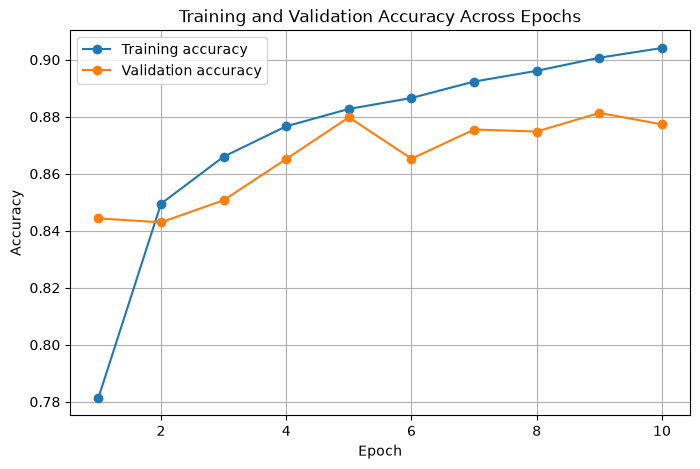

In [57]:
# Inspect the existing history object's keys instead of assuming their names
history_keys = list(history.keys())
print("Available history keys:", history_keys)

# Find the training-accuracy key: contains "train" and either "acc" or "metric"
train_acc_key = next(
    key for key in history_keys
    if "train" in key.lower() and ("acc" in key.lower() or "metric" in key.lower())
)

# Find a validation-accuracy key, if one exists: contains "val"/"valid" and "acc"/"metric"
valid_acc_key = next(
    (
        key for key in history_keys
        if ("val" in key.lower() or "valid" in key.lower())
        and ("acc" in key.lower() or "metric" in key.lower())
    ),
    None,
)
print(f"Using '{train_acc_key}' for training accuracy and '{valid_acc_key}' for validation accuracy.")

# The accuracy metric was stored as a proportion (0-1) by torchmetrics, so both
# series are already on a consistent scale and need no conversion here
train_accuracy = history[train_acc_key]
epoch_numbers = range(1, len(train_accuracy) + 1)  # epochs are 1-indexed for display

plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, train_accuracy, label="Training accuracy", marker="o")

# Only add the validation line if the history actually tracked it
if valid_acc_key is not None:
    valid_accuracy = history[valid_acc_key]
    plt.plot(epoch_numbers, valid_accuracy, label="Validation accuracy", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Across Epochs")
plt.legend()
plt.grid(True)
plt.show()